# Entrenamiento — Clasificación de parches (DeiT-tiny vs MobileViT-small)

Fine-tuning de Vision Transformers ligeros sobre parches 224×224 del dataset CarDD.
**Tarea:** clasificación de 7 clases (6 tipos de daño + fondo).

**Diferencia clave con `02_entrenamiento_segmentacion_mask2former.ipynb`:** esta notebook realiza **clasificación** sobre parches pre-extraídos — no detecta ni segmenta sobre imagen completa.

Se comparan DeiT-tiny y MobileViT-small en macro F1, F1 por clase y curvas de entrenamiento.

## Setup

In [1]:
# !pip install -q -r ../requirements.txt

In [2]:
import sys
from pathlib import Path

ROOT = Path("../").resolve()
sys.path.insert(0, str(ROOT / "src"))

import torch
from vit.models.factory import cargar_modelo
from vit.data.dataloader import get_dataloaders
from vit.train.trainer import entrenar
from vit.eval.metricas import calcular_metricas, plot_confusion_matrix

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("device:", device)

NUM_CLASES  = 7   # dent, scratch, crack, glass_shatter, tire_flat, lamp_broken, fondo
BATCH_SIZE  = 32

device: mps


## Entrenamiento — DeiT-tiny

In [3]:
NOMBRE_DEIT = "facebook/deit-tiny-patch16-224"

modelo_deit, proc_deit = cargar_modelo(NOMBRE_DEIT, num_clases=NUM_CLASES)

dl_train_deit, dl_val_deit, dl_test_deit = get_dataloaders(
    procesadores={"train": proc_deit, "eval": proc_deit},
    batch_size=BATCH_SIZE,
)

config_deit = {
    "device":     device,
    "lr":         2e-4,
    "epochs":     20,
    "patience":   5,
    "output_dir": str(ROOT / "checkpoints" / "deit_tiny"),
}

history_deit = entrenar(modelo_deit, dl_train_deit, dl_val_deit, config_deit)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: facebook/deit-tiny-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 192]) vs model:torch.Size([7, 192])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([7])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Cargando anotaciones [train] desde /Users/matiastripode/Especializacion_AI/07_vision_III/car-damage-vit/data/raw/annotations/train.json...
  → 1971 imágenes | 4332 anotaciones
Construyendo lista de parches...
  → 8638 parches en total
Cargando anotaciones [validation] desde /Users/matiastripode/Especializacion_AI/07_vision_III/car-damage-vit/data/raw/annotations/validation.json...
  → 422 imágenes | 1005 anotaciones
Construyendo lista de parches...
  → 1999 parches en total
Cargando anotaciones [test] desde /Users/matiastripode/Especializacion_AI/07_vision_III/car-damage-vit/data/raw/annotations/test.json...
  → 423 imágenes | 874 anotaciones
Construyendo lista de parches...
  → 1739 parches en total
[00] train_loss=0.8291 | val_loss=1.0233 | val_f1=0.5730 | val_acc=0.6128 | 91.4s
  → nuevo mejor checkpoint (val_f1=0.5730)
[01] train_loss=0.5395 | val_loss=1.1803 | val_f1=0.5568 | val_acc=0.5673 | 91.0s
  → sin mejora (1/5)
[02] train_loss=0.4726 | val_loss=0.8550 | val_f1=0.6359 | val

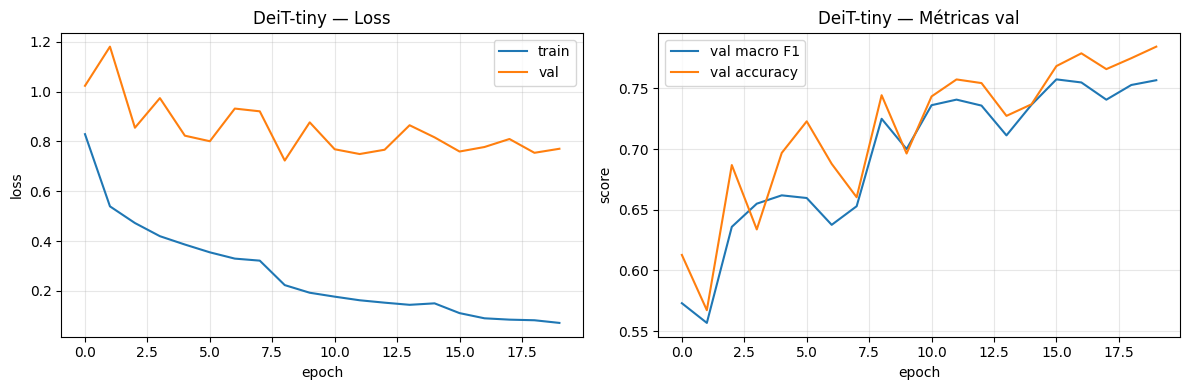

In [4]:
import matplotlib.pyplot as plt

def plot_curves(history, titulo):
    epochs = range(len(history))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, [h["train_loss"] for h in history], label="train")
    ax1.plot(epochs, [h["val_loss"]   for h in history], label="val")
    ax1.set_title(f"{titulo} — Loss")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("loss")
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, [h["val_f1"]  for h in history], label="val macro F1")
    ax2.plot(epochs, [h["val_acc"] for h in history], label="val accuracy")
    ax2.set_title(f"{titulo} — Métricas val")
    ax2.set_xlabel("epoch"); ax2.set_ylabel("score")
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_curves(history_deit, "DeiT-tiny")

### Evaluación DeiT-tiny en test

Checkpoint: epoch=15 | val_f1=0.7574
               precision    recall  f1-score   support

         dent       0.63      0.69      0.66       268
      scratch       0.65      0.81      0.72       317
        crack       0.82      0.63      0.71        87
glass_shatter       0.71      0.85      0.77        74
    tire_flat       0.84      0.79      0.82        39
  lamp_broken       0.76      0.80      0.78        89
        fondo       0.87      0.77      0.81       865

     accuracy                           0.76      1739
    macro avg       0.75      0.76      0.75      1739
 weighted avg       0.78      0.76      0.76      1739



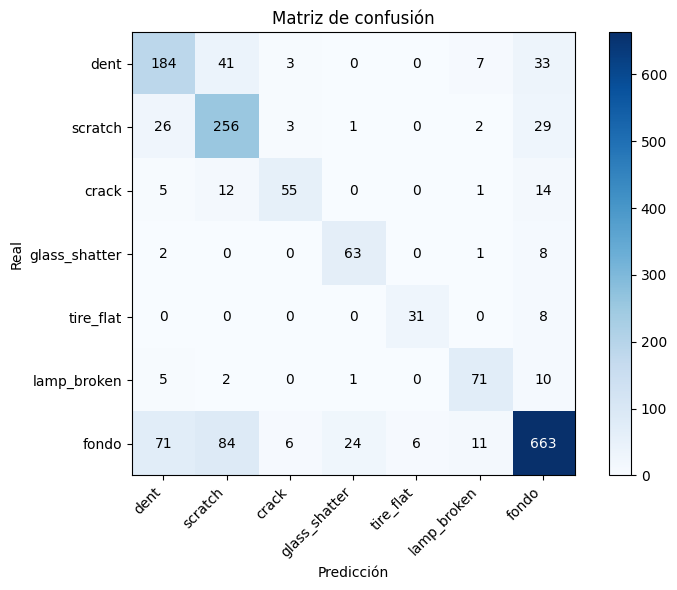

In [5]:
from vit.data.dataset import CLASES_CON_FONDO

def evaluar_en_test(modelo, dl_test, nombres_clases, device):
    modelo.eval()
    modelo.to(device)
    preds_all, labels_all = [], []
    with torch.no_grad():
        for pixel_values, labels in dl_test:
            pixel_values = pixel_values.to(device)
            out = modelo(pixel_values=pixel_values)
            preds_all.extend(out.logits.argmax(dim=-1).cpu().tolist())
            labels_all.extend(labels.tolist())
    return calcular_metricas(labels_all, preds_all, nombres_clases)

# Cargar mejor checkpoint
ckpt_deit = torch.load(ROOT / "checkpoints" / "deit_tiny" / "best_model.pt", map_location="cpu")
modelo_deit.load_state_dict(ckpt_deit["model_state_dict"])
print(f"Checkpoint: epoch={ckpt_deit['epoch']} | val_f1={ckpt_deit['val_f1']:.4f}")

metricas_deit = evaluar_en_test(modelo_deit, dl_test_deit, CLASES_CON_FONDO, device)
plot_confusion_matrix(metricas_deit["confusion_matrix"], CLASES_CON_FONDO)

## Entrenamiento — MobileViT-small

In [6]:
NOMBRE_MVIT = "apple/mobilevit-small"

modelo_mvit, proc_mvit = cargar_modelo(NOMBRE_MVIT, num_clases=NUM_CLASES)

dl_train_mvit, dl_val_mvit, dl_test_mvit = get_dataloaders(
    procesadores={"train": proc_mvit, "eval": proc_mvit},
    batch_size=BATCH_SIZE,
)

config_mvit = {
    "device":     device,
    "lr":         2e-4,
    "epochs":     20,
    "patience":   5,
    "output_dir": str(ROOT / "checkpoints" / "mobilevit_small"),
}

history_mvit = entrenar(modelo_mvit, dl_train_mvit, dl_val_mvit, config_mvit)

Loading weights:   0%|          | 0/347 [00:00<?, ?it/s]

MobileViTForImageClassification LOAD REPORT from: apple/mobilevit-small
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([7])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 640]) vs model:torch.Size([7, 640])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Cargando anotaciones [train] desde /Users/matiastripode/Especializacion_AI/07_vision_III/car-damage-vit/data/raw/annotations/train.json...
  → 1971 imágenes | 4332 anotaciones
Construyendo lista de parches...
  → 8638 parches en total
Cargando anotaciones [validation] desde /Users/matiastripode/Especializacion_AI/07_vision_III/car-damage-vit/data/raw/annotations/validation.json...
  → 422 imágenes | 1005 anotaciones
Construyendo lista de parches...
  → 1999 parches en total
Cargando anotaciones [test] desde /Users/matiastripode/Especializacion_AI/07_vision_III/car-damage-vit/data/raw/annotations/test.json...
  → 423 imágenes | 874 anotaciones
Construyendo lista de parches...
  → 1739 parches en total
[00] train_loss=1.0201 | val_loss=1.1575 | val_f1=0.5917 | val_acc=0.6208 | 167.9s
  → nuevo mejor checkpoint (val_f1=0.5917)
[01] train_loss=0.5759 | val_loss=0.9188 | val_f1=0.6661 | val_acc=0.6928 | 164.2s
  → nuevo mejor checkpoint (val_f1=0.6661)
[02] train_loss=0.4597 | val_loss=0.81

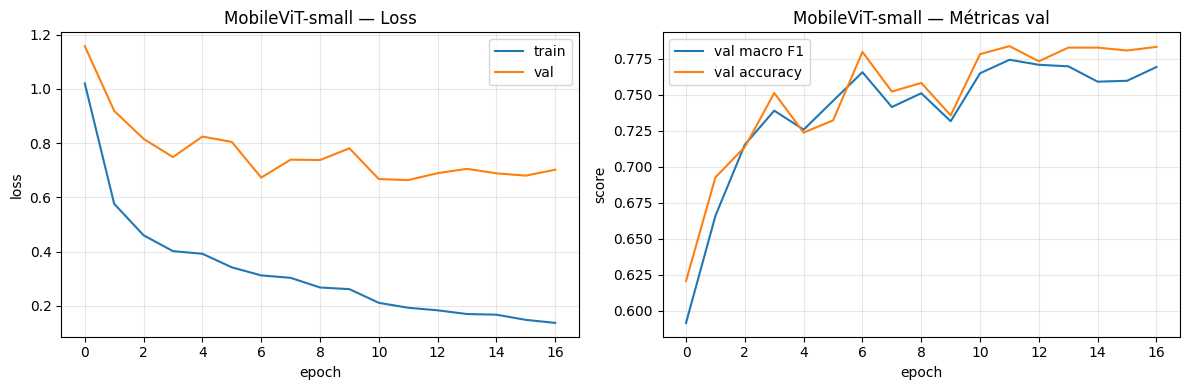

In [7]:
plot_curves(history_mvit, "MobileViT-small")

### Evaluación MobileViT-small en test

Checkpoint: epoch=11 | val_f1=0.7745
               precision    recall  f1-score   support

         dent       0.66      0.76      0.71       268
      scratch       0.71      0.78      0.74       317
        crack       0.59      0.74      0.66        87
glass_shatter       0.73      0.89      0.80        74
    tire_flat       0.81      0.74      0.77        39
  lamp_broken       0.78      0.82      0.80        89
        fondo       0.89      0.78      0.83       865

     accuracy                           0.78      1739
    macro avg       0.74      0.79      0.76      1739
 weighted avg       0.79      0.78      0.78      1739



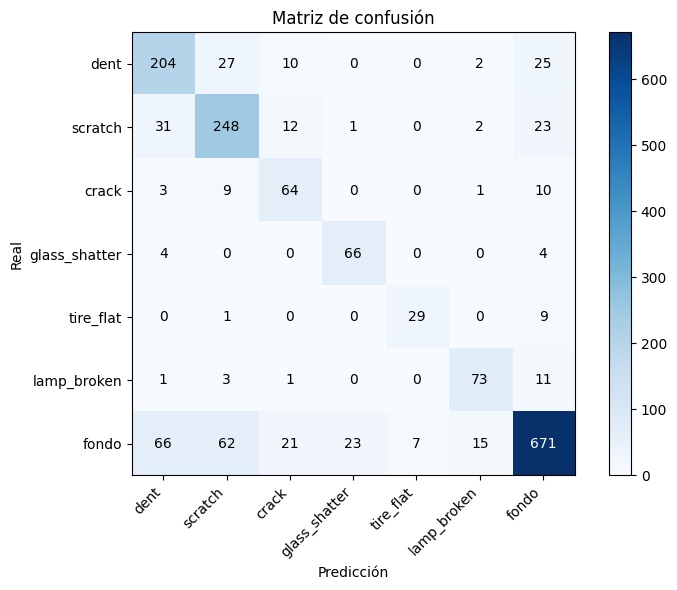

In [8]:
ckpt_mvit = torch.load(ROOT / "checkpoints" / "mobilevit_small" / "best_model.pt", map_location="cpu")
modelo_mvit.load_state_dict(ckpt_mvit["model_state_dict"])
print(f"Checkpoint: epoch={ckpt_mvit['epoch']} | val_f1={ckpt_mvit['val_f1']:.4f}")

metricas_mvit = evaluar_en_test(modelo_mvit, dl_test_mvit, CLASES_CON_FONDO, device)
plot_confusion_matrix(metricas_mvit["confusion_matrix"], CLASES_CON_FONDO)

## Comparación de resultados

In [9]:
# Tabla resumen
print(f"{'modelo':<20} {'accuracy':>9} {'macro F1':>9}")
print("-" * 42)
for nombre, m in [("DeiT-tiny", metricas_deit), ("MobileViT-small", metricas_mvit)]:
    print(f"{nombre:<20} {m['accuracy']:>9.4f} {m['f1_macro']:>9.4f}")

modelo                accuracy  macro F1
------------------------------------------
DeiT-tiny               0.7608    0.7531
MobileViT-small         0.7792    0.7596


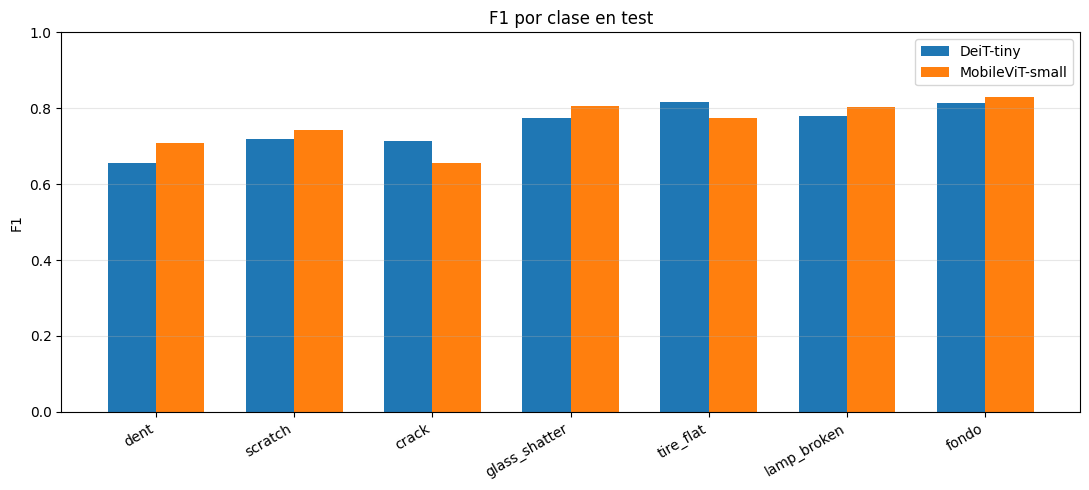

In [10]:
# F1 por clase
import numpy as np

clases   = CLASES_CON_FONDO
f1_deit  = [metricas_deit["f1_por_clase"][c]  for c in clases]
f1_mvit  = [metricas_mvit["f1_por_clase"][c]  for c in clases]

x    = np.arange(len(clases))
ancho = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - ancho/2, f1_deit, ancho, label="DeiT-tiny")
ax.bar(x + ancho/2, f1_mvit, ancho, label="MobileViT-small")
ax.set_xticks(x)
ax.set_xticklabels(clases, rotation=30, ha="right")
ax.set_ylabel("F1")
ax.set_title("F1 por clase en test")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

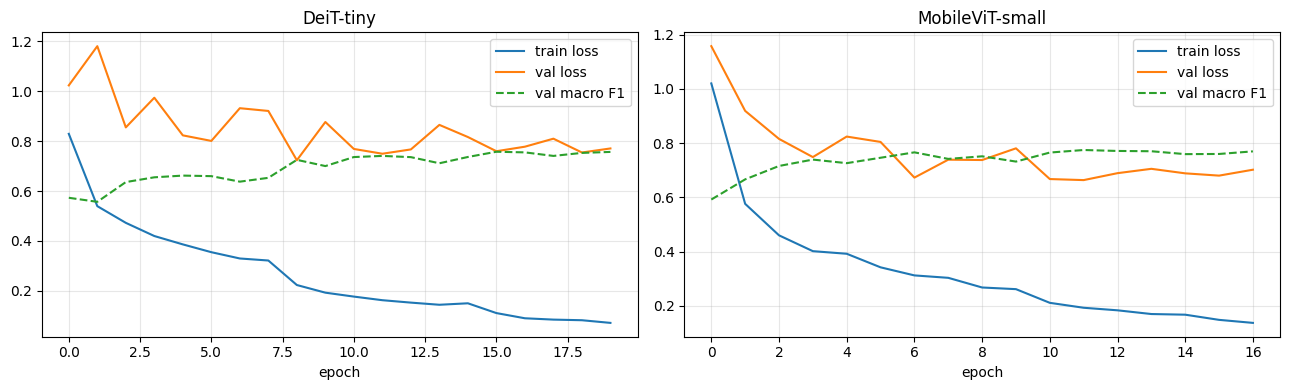

In [11]:
# Curvas de entrenamiento lado a lado
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, history, titulo in [
    (axes[0], history_deit, "DeiT-tiny"),
    (axes[1], history_mvit, "MobileViT-small"),
]:
    epochs = range(len(history))
    ax.plot(epochs, [h["train_loss"] for h in history], label="train loss")
    ax.plot(epochs, [h["val_loss"]   for h in history], label="val loss")
    ax.plot(epochs, [h["val_f1"]     for h in history], label="val macro F1", linestyle="--")
    ax.set_title(titulo)
    ax.set_xlabel("epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()